<a href="https://colab.research.google.com/github/00015775/learning-lab/blob/learn%2Fpytorch/pytorch/notebooks/03_experiment_timm_cont.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Transer learnig with `timm` models and pytorch

**source**: https://www.kaggle.com/code/hinepo/transfer-learning-with-timm-models-and-pytorch

In [1]:
!pip install -q kaggle

In [2]:
import os
from google.colab import userdata

# sometimes need to try out either KAGGLE_KEY or KAGGLE_API_TOKEN if error
os.environ["KAGGLE_KEY"] = userdata.get("KAGGLE_API_TOKEN")
os.environ["KAGGLE_API_TOKEN"] = userdata.get("KAGGLE_API_TOKEN")
os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")

In [3]:
!kaggle competitions list

ref                                                                                 deadline             category                reward  teamCount  userHasEntered  
----------------------------------------------------------------------------------  -------------------  ---------------  -------------  ---------  --------------  
https://www.kaggle.com/competitions/ai-mathematical-olympiad-progress-prize-3       2026-04-15 23:59:00  Featured         2,207,152 Usd       1895           False  
https://www.kaggle.com/competitions/vesuvius-challenge-surface-detection            2026-02-13 23:59:00  Research           200,000 Usd       1271           False  
https://www.kaggle.com/competitions/stanford-rna-3d-folding-2                       2026-03-25 23:59:00  Featured           100,000 Usd        772           False  
https://www.kaggle.com/competitions/med-gemma-impact-challenge                      2026-02-24 23:59:00  Featured           100,000 Usd        107           False  
https://ww

In [4]:
!kaggle competitions download -c digit-recognizer

  0% 0.00/15.3M [00:00<?, ?B/s]
100% 15.3M/15.3M [00:00<00:00, 652MB/s]


In [5]:
!unzip digit-recognizer.zip

Archive:  digit-recognizer.zip
  inflating: sample_submission.csv   
  inflating: test.csv                
  inflating: train.csv               


In [6]:
from pathlib import Path

DIGIT_DIR = Path("./kaggle_datasets")
DIGIT_DIR.mkdir(parents=True, exist_ok=True)

In [7]:
!mv train.csv test.csv sample_submission.csv ./kaggle_datasets/

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import time
import random
import os

from sklearn.model_selection import train_test_split

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam, AdamW, RMSprop
from torch.optim.lr_scheduler import CosineAnnealingLR, ReduceLROnPlateau

import albumentations as A

try:
  import timm
  from torchinfo import summary
except ModuleNotFoundError as e:
  !pip3 install -q timm
  !pip3 install -q torchinfo
  import timm
  from torchinfo import summary


In [9]:
device = torch.device("cuda" if torch.cuda.is_available()\
                      else "mps" if torch.backends.mps.is_available()\
                      else "cpu")
print(device)

cuda


In [10]:
print("Timm version:", timm.__version__)
print("Torch version:", torch.__version__)

Timm version: 1.0.24
Torch version: 2.9.0+cu126


In [11]:
INPUT_PATH = "./kaggle_datasets/"
OUTPUT_PATH = "./" # where to save the weights of the model

train = pd.read_csv(INPUT_PATH + "train.csv")
test = pd.read_csv(INPUT_PATH + "test.csv")

In [12]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)

print("\nTrain dataset:")
display(train[:5])

print("\nTest dataset:")
display(test[:5])

Train shape: (42000, 785)
Test shape: (28000, 784)

Train dataset:


,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0



Test dataset:


,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [13]:
# write the configuration class to hold of the hyperparameters
# helps to avoid making changes in hypermaters everywhere

class CFG:
  DEBUG = False # used just to check whether the training loop works

  IMG_HEIGHT = 28
  IMG_WIDTH = 28
  N_CLASS = len(np.unique(train["label"]))

  # train and validation splits
  split_fraction = 0.95

  model_name = "resnet50" # has 50mln parameters

  print_freq = 100
  BATCH_SIZE = 1024
  N_EPOCHS = 3 if DEBUG else 40 # if checking for functionality of the training loop, then do only 3 epochs


  save_best_loss = False
  save_best_acc = True

  optimizer = "rmsprop"

  LEARNING_RATE = 1e-3

  # helps to avoid some weights having very large values
  weight_decay = 0.1
  penalty = 0.01
  rms_momentum = 0

  scheduler = "ReduceLROnPlateau"

  plateau_factor = 0.5
  plateau_patience = 3
  cosine_T_max = 4
  cosine_eta_min = 1e-8
  verbose = True

  probability = 0.6

  random_seed = 88


In [14]:
if CFG.DEBUG: # if set to DEBUG
  train = train.sample(frac=0.1).reset_index(drop=True)
  CFG.N_CLASS = len(np.unique(train["label"]))

print(f"Using {CFG.N_CLASS} classes to train.")

Using 10 classes to train.


In [15]:
print("DEBUG?:", CFG.DEBUG)
print("Train shape:", train.shape)
print("Test shape:", test.shape)

print(f"\nImage shape (H, W): ({CFG.IMG_HEIGHT}, {CFG.IMG_WIDTH})")
print(f"Number of classes to train, {CFG.N_CLASS} classes.")

DEBUG?: False
Train shape: (42000, 785)
Test shape: (28000, 784)

Image shape (H, W): (28, 28)
Number of classes to train, 10 classes.


In [16]:
CFG.random_seed

88

In [17]:
def seed_torch(seed):
  random.seed(seed)
  os.environ['PYTHONHASHSEED'] = str(seed)
  torch.manual_seed(seed)
  np.random.seed(seed)
  torch.cuda.manual_seed(seed)
  torch.backends.cudnn.deterministic = True

seed_torch(seed = CFG.random_seed)

In [18]:
print("Before split:")
print(" train shape:", train.shape)

train_df, valid_df = train_test_split(
    train,
    test_size = (1 - CFG.split_fraction),
    random_state = CFG.random_seed
)

print("\nAfter split:")
print(" train_df shape:", train_df.shape)
print(" valid_df shape:", valid_df.shape)

# remember that if there are only two splits available, train and test
# then the validation split is taken from the training split

Before split:
 train shape: (42000, 785)

After split:
 train_df shape: (39899, 785)
 valid_df shape: (2101, 785)


### Dataset Class

In [19]:
# for training and validation
class DigitDataset(Dataset):
  def __init__(self, df, X_col, y_col, augmentations = None):
    self.df = df
    self.features = df[X_col].values/255.0
    self.targets = df[y_col].values.reshape((-1, 1))
    self.augmentations = augmentations

  def __len__(self):
    return len(self.features)

  def __getitem__(self, idx):
    image = self.features[idx].reshape((28, 28))
    label = self.targets[idx]

    if self.augmentations is not None:
      augmented = self.augmentations(image=image)
      image = augmented["image"]
      image = torch.from_numpy(image).float()
      image = torch.stack([image, image, image], dim = 0) # stack images, to have C=3

      return image, label
    else:
      image = torch.from_numpy(image).float()
      image = torch.stack([image, image, image], dim = 0)

      return image, label

In [20]:
# for testing/inferencing on unseen data
class DigitInferenceDataset(Dataset):
  def __init__(self, df, augmentations = None):
    self.df = df
    self.features = df[:].values/255.0
    self.augmentations = augmentations

  def __len__(self):
    return len(self.features)

  def __getitem__(self, idx):
    image = self.features[idx].reshape((28, 28))
    image = torch.from_numpy(image).float() # float64
    image = torch.stack([image, image, image], dim=0) # results in C=3
    return image

  # only returns the features and not the labels
  # because in real-world usage the labels are not provided
  # testing simulates the unseen data on real-world use-case

### Data Augmentation with `albumentations`

In [21]:
transform_train = A.Compose([
    A.Rotate(limit=40, p=CFG.probability),
    A.Affine(p=CFG.probability),
    A.Downscale(scale_range=[0.7, 0.7], p=CFG.probability)
    # ToTensorV2()
])

In [22]:
transform_valid = A.Compose([
    # ToTensorV2()
])

In [23]:
y_col = "label"
X_col = [c for c in train.columns if c != "label"]

len(y_col), len(X_col)

(5, 784)

### Transer learning: `timm`

In [24]:
class DigitModel(nn.Module):
  def __init__(self,
               model_name = CFG.model_name,
               pretrained = True):
    super().__init__()
    self.model_name = model_name
    self.cnn = timm.create_model(self.model_name,
                                 pretrained = pretrained, # True
                                 num_classes = CFG.N_CLASS
                                 )

  def forward(self, x):
    x = self.cnn(x)
    return x

In [25]:
CFG.model_name

'resnet50'

In [26]:
m = DigitModel()

summary(m, (64, 3, 7, 7))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

Layer (type:depth-idx)                        Output Shape              Param #
DigitModel                                    [64, 10]                  --
├─ResNet: 1-1                                 [64, 10]                  --
│    └─Conv2d: 2-1                            [64, 64, 4, 4]            9,408
│    └─BatchNorm2d: 2-2                       [64, 64, 4, 4]            128
│    └─ReLU: 2-3                              [64, 64, 4, 4]            --
│    └─MaxPool2d: 2-4                         [64, 64, 2, 2]            --
│    └─Sequential: 2-5                        [64, 256, 2, 2]           --
│    │    └─Bottleneck: 3-1                   [64, 256, 2, 2]           75,008
│    │    └─Bottleneck: 3-2                   [64, 256, 2, 2]           70,400
│    │    └─Bottleneck: 3-3                   [64, 256, 2, 2]           70,400
│    └─Sequential: 2-6                        [64, 512, 1, 1]           --
│    │    └─Bottleneck: 3-4                   [64, 512, 1, 1]           379,392

In [27]:
# trainable parameters, but need to retrain only the classifer layer
sum([p.numel() for p in m.parameters() if p.requires_grad == True])


23528522

### `list_models`

In [28]:
print("Number of total model layers available:", len(timm.list_models(pretrained=False)))
print("Number of total pretrained models available:", len(timm.list_models(pretrained=True)))

print(f"\nResnet models: {timm.list_models("resnet50*")}")

Number of total model layers available: 1284
Number of total pretrained models available: 1699

Resnet models: ['resnet50', 'resnet50_clip', 'resnet50_clip_gap', 'resnet50_gn', 'resnet50_mlp', 'resnet50c', 'resnet50d', 'resnet50s', 'resnet50t', 'resnet50x4_clip', 'resnet50x4_clip_gap', 'resnet50x16_clip', 'resnet50x16_clip_gap', 'resnet50x64_clip', 'resnet50x64_clip_gap']


In [29]:
vgg = timm.create_model("vgg16")

vgg.head.fc

Linear(in_features=4096, out_features=1000, bias=True)

### Optimizer

In [30]:
def get_optimizer(lr=CFG.LEARNING_RATE):
  if CFG.optimizer == "adam":
    optimizer = Adam(model.parameters(),
                     lr=lr,
                     weight_decay=CFG.weight_decay,
                     amsgrad=True)

  elif CFG.optimizer == 'adamw':
      optimizer = AdamW(model.parameters(),
                        lr = lr,
                        weight_decay = CFG.weight_decay)

  elif CFG.optimizer == 'rmsprop':
      optimizer = RMSprop(model.parameters(),
                          lr = lr,
                          weight_decay = CFG.penalty,
                          momentum = CFG.rms_momentum)
  else:
      print('Optimizer is not defined')

  return optimizer

### LR Scheduler

In [31]:
def get_scheduler(optimizer: torch.optim.Optimizer):

  if CFG.scheduler=='ReduceLROnPlateau':
      scheduler = ReduceLROnPlateau(optimizer,
                                    mode='max',
                                    factor = CFG.plateau_factor,
                                    patience = CFG.plateau_patience)

  elif CFG.scheduler=='CosineAnnealingLR':
      scheduler = CosineAnnealingLR(optimizer,
                                    T_max = CFG.cosine_T_max,
                                    eta_min = CFG.cosine_eta_min)

  else:
      print('LR Scheduler is not defined')

  return scheduler

### Training function

In [32]:
import time

def train_fn(train_loader, model, criterion, optimizer, device):
  model.train()

  size = len(train_loader.dataset)
  num_batches = len(train_loader)

  loss, correct = 0, 0

  for batch, (X, y) in enumerate(train_loader):
    start = time.time()

    device = torch.device(device)

    X, y = X.to(device), y.to(device)



    pred = model(X)
    loss = criterion(pred, y.long().squeeze())
    current = batch * len(X)

    optimizer.zero_grad()

    loss.backward()
    optimizer.step()

    # choose the class dimension for argmax and softmax
    y_pred, y_true = torch.argmax(pred, dim=1), y.long().squeeze()
    correct += (y_pred == y_true).type(torch.float).sum().item()

    end = time.time()
    time_delta = np.round(end - start, 3)

    loss, current = np.round(loss.item(), 5), batch * len(X)

  correct /= size
  loss /= num_batches

  print(f"Train: Accuracy: {(100*correct):>0.2f}%, Avg loss: {loss:>5f} \n")

  return loss, correct


### Validation function

In [33]:
import time

import time

def valid_fn(valid_loader, model, criterion, device):
  model.eval()

  size = len(valid_loader.dataset)
  num_batches = len(valid_loader)

  loss, correct = 0, 0


  with torch.no_grad(): # disable gradients
    for batch, (X, y) in enumerate(valid_loader):

      start = time.time()

      device = torch.device(device)
      X, y = X.to(device), y.to(device)

      # compute predictions and loss
      pred = model(X)
      loss = criterion(pred, y.long().squeeze())
      current = batch * len(X)

      # sum correct predictions
      y_pred, y_true = torch.argmax(pred, dim=1), y.long().squeeze()
      correct += (y_pred == y_true).type(torch.float).sum().item()

      end = time.time()
      time_delta = np.round(end - start, 3)

      # log
      loss, current = np.round(loss.item(), 5), batch * len(X)

  correct /= size # epoch accuracy
  loss /= num_batches # epoch loss

  print(f"Valid: Accuracy: {(100*correct):>0.2f}%, Avg loss: {loss:>5f} \n")

  return loss, correct

In [34]:
m = DigitModel()

summary(m, (64, 3, 7, 7))

Layer (type:depth-idx)                        Output Shape              Param #
DigitModel                                    [64, 10]                  --
├─ResNet: 1-1                                 [64, 10]                  --
│    └─Conv2d: 2-1                            [64, 64, 4, 4]            9,408
│    └─BatchNorm2d: 2-2                       [64, 64, 4, 4]            128
│    └─ReLU: 2-3                              [64, 64, 4, 4]            --
│    └─MaxPool2d: 2-4                         [64, 64, 2, 2]            --
│    └─Sequential: 2-5                        [64, 256, 2, 2]           --
│    │    └─Bottleneck: 3-1                   [64, 256, 2, 2]           75,008
│    │    └─Bottleneck: 3-2                   [64, 256, 2, 2]           70,400
│    │    └─Bottleneck: 3-3                   [64, 256, 2, 2]           70,400
│    └─Sequential: 2-6                        [64, 512, 1, 1]           --
│    │    └─Bottleneck: 3-4                   [64, 512, 1, 1]           379,392

In [35]:
# trainable parameters, but need to retrain only the classifer layer
sum([p.numel() for p in m.parameters() if p.requires_grad == True])

23528522

In [36]:
for name, param in m.named_parameters():
  print(name, param.shape)

cnn.conv1.weight torch.Size([64, 3, 7, 7])
cnn.bn1.weight torch.Size([64])
cnn.bn1.bias torch.Size([64])
cnn.layer1.0.conv1.weight torch.Size([64, 64, 1, 1])
cnn.layer1.0.bn1.weight torch.Size([64])
cnn.layer1.0.bn1.bias torch.Size([64])
cnn.layer1.0.conv2.weight torch.Size([64, 64, 3, 3])
cnn.layer1.0.bn2.weight torch.Size([64])
cnn.layer1.0.bn2.bias torch.Size([64])
cnn.layer1.0.conv3.weight torch.Size([256, 64, 1, 1])
cnn.layer1.0.bn3.weight torch.Size([256])
cnn.layer1.0.bn3.bias torch.Size([256])
cnn.layer1.0.downsample.0.weight torch.Size([256, 64, 1, 1])
cnn.layer1.0.downsample.1.weight torch.Size([256])
cnn.layer1.0.downsample.1.bias torch.Size([256])
cnn.layer1.1.conv1.weight torch.Size([64, 256, 1, 1])
cnn.layer1.1.bn1.weight torch.Size([64])
cnn.layer1.1.bn1.bias torch.Size([64])
cnn.layer1.1.conv2.weight torch.Size([64, 64, 3, 3])
cnn.layer1.1.bn2.weight torch.Size([64])
cnn.layer1.1.bn2.bias torch.Size([64])
cnn.layer1.1.conv3.weight torch.Size([256, 64, 1, 1])
cnn.layer1.

In [37]:
for name, param in m.named_parameters():
  if "cnn.fc" in name:
    param.requires_grad = True
  else:
    param.requires_grad = False

In [38]:
# trainable parameters, but need to retrain only the classifer layer
sum([p.numel() for p in m.parameters() if p.requires_grad == True])

20490

### Run training

In [39]:
from tqdm.auto import tqdm

start = time.time()

loss_fn = nn.CrossEntropyLoss()

device = torch.device(device)
model = DigitModel().to(device) # move to the same device

print('\n ******************************* Using backbone: ', CFG.model_name, " ******************************* \n")

optimizer = get_optimizer(lr = CFG.LEARNING_RATE)

scheduler = get_scheduler(optimizer)

y_col = "label"
X_col = [c for c in train.columns if c!= "label"]

train_dataset = DigitDataset(
    train_df,
    X_col,
    y_col,
    augmentations=transform_train
)

valid_dataset = DigitDataset(
    valid_df,
    X_col,
    y_col,
    augmentations=transform_valid
)

train_dataloader = DataLoader(
    train_dataset,
    batch_size = CFG.BATCH_SIZE,
    shuffle = True
)

valid_dataloader = DataLoader(
    valid_dataset,
    batch_size = CFG.BATCH_SIZE,
    shuffle = False
)

train_loss_history = []
train_acc_history = []
valid_loss_history = []
valid_acc_history = []
LR_history = []

best_loss = np.inf
best_epoch_loss = 0
best_acc = 0
best_epoch_acc = 0



 ******************************* Using backbone:  resnet50  ******************************* 



In [40]:
# very important, or otherwise would take really long
# since pre-trained weights are again trained from scratch
# but after freezing feature extractor layers, only 20k parameters are being trained
# but when doing from scratch, the n# for parameters would have been a lot more than 20k

# for some reason showing very low accuracy, so maybe need to unfreeze all layers
# uncomment below is no progress with training all layers wih 25mln parameters


for name, param in model.named_parameters():
  if "cnn.fc" in name:
    param.requires_grad = True
  else:
    param.requires_grad = False

# # trainable parameters, but need to retrain only the classifer layer
# sum([p.numel() for p in model.parameters() if p.requires_grad == True])

In [41]:
sum([p.numel() for p in model.parameters() if p.requires_grad == True])

20490

In [42]:
print("Starting Training...\n")

start_train_time = time.time()

for epoch in tqdm(range(0, CFG.N_EPOCHS)):
  print(f"\n-------------------------------   Epoch {epoch + 1}   -------------------------------\n")

  start_epoch_time = time.time()

  # train
  train_loss, train_acc = train_fn(train_dataloader,
                                   model,
                                   loss_fn,
                                   optimizer,
                                   device)
  train_loss_history.append(train_loss)
  train_acc_history.append(train_acc)


  # validations
  valid_loss, valid_acc = valid_fn(valid_dataloader,
                                   model,
                                   loss_fn,
                                   device)
  valid_loss_history.append(valid_loss)
  valid_acc_history.append(valid_acc)

  if isinstance(scheduler, ReduceLROnPlateau):
    scheduler.step(valid_loss)

  elif isinstance(scheduler, CosineAnnealingLR):
    scheduler.step()

  # to observe how the value of learning rate is dynamically changed
  # based on accuracy and epochs ...
  for param_group in optimizer.param_groups:
    LR_history.append(param_group["lr"])

  if valid_loss < best_loss:
    best_epoch_loss = epoch + 1
    best_loss = valid_loss
    if CFG.save_best_loss:
      torch.save(obj = model.state_dict(),
                 f = OUTPUT_PATH + f"DigitModel_ep{best_epoch_loss}.pth")

  if valid_acc > best_acc:
    best_epoch_acc = epoch + 1
    best_acc = valid_acc
    if CFG.save_best_acc:
      torch.save(obj = model.state_dict(),
                f = OUTPUT_PATH + f"DigitModel_ep{best_epoch_acc}.pth")


  end_epoch_time = time.time()
  time_delta = np.round(end_epoch_time - start_epoch_time, 3)
  print(f"\n\nEpoch Elapsed Time: {time_delta}")

end_train_time = time.time()
print(f"\n\nTotal Elapsed Time: {(np.round(end_train_time - start_train_time, 3))/60:.4f} min")
print("Done!")


Starting Training...



  0%|          | 0/40 [00:00<?, ?it/s]


-------------------------------   Epoch 1   -------------------------------

Train: Accuracy: 34.51%, Avg loss: 0.049980 

Valid: Accuracy: 14.99%, Avg loss: 0.761040 



Epoch Elapsed Time: 23.237

-------------------------------   Epoch 2   -------------------------------

Train: Accuracy: 38.47%, Avg loss: 0.048762 

Valid: Accuracy: 19.80%, Avg loss: 0.743523 



Epoch Elapsed Time: 30.011

-------------------------------   Epoch 3   -------------------------------

Train: Accuracy: 38.98%, Avg loss: 0.047789 

Valid: Accuracy: 19.90%, Avg loss: 0.747153 



Epoch Elapsed Time: 22.491

-------------------------------   Epoch 4   -------------------------------

Train: Accuracy: 39.67%, Avg loss: 0.047141 

Valid: Accuracy: 19.51%, Avg loss: 0.741527 



Epoch Elapsed Time: 28.743

-------------------------------   Epoch 5   -------------------------------

Train: Accuracy: 39.39%, Avg loss: 0.047029 

Valid: Accuracy: 20.42%, Avg loss: 0.737760 



Epoch Elapsed Time: 35.468

----

### Plot Epochs

In [43]:
print(f"Best validation loss: {round(best_loss, 5)}")
print(f"Best epoch (loss criteria in validation): {best_epoch_loss}")
print(f"\nBest validation accuracy: {round(best_acc * 100, 5)}")
print(f"Best epoch (accuracy criteria in validation): {best_epoch_loss}")

Best validation loss: 0.722
Best epoch (loss criteria in validation): 28

Best validation accuracy: 23.60781
Best epoch (accuracy criteria in validation): 28


In [44]:
!du -h DigitModel_ep1.pth

91M	DigitModel_ep1.pth


In [45]:
sum([p.numel() for p in model.parameters() if param.requires_grad == True])

23528522

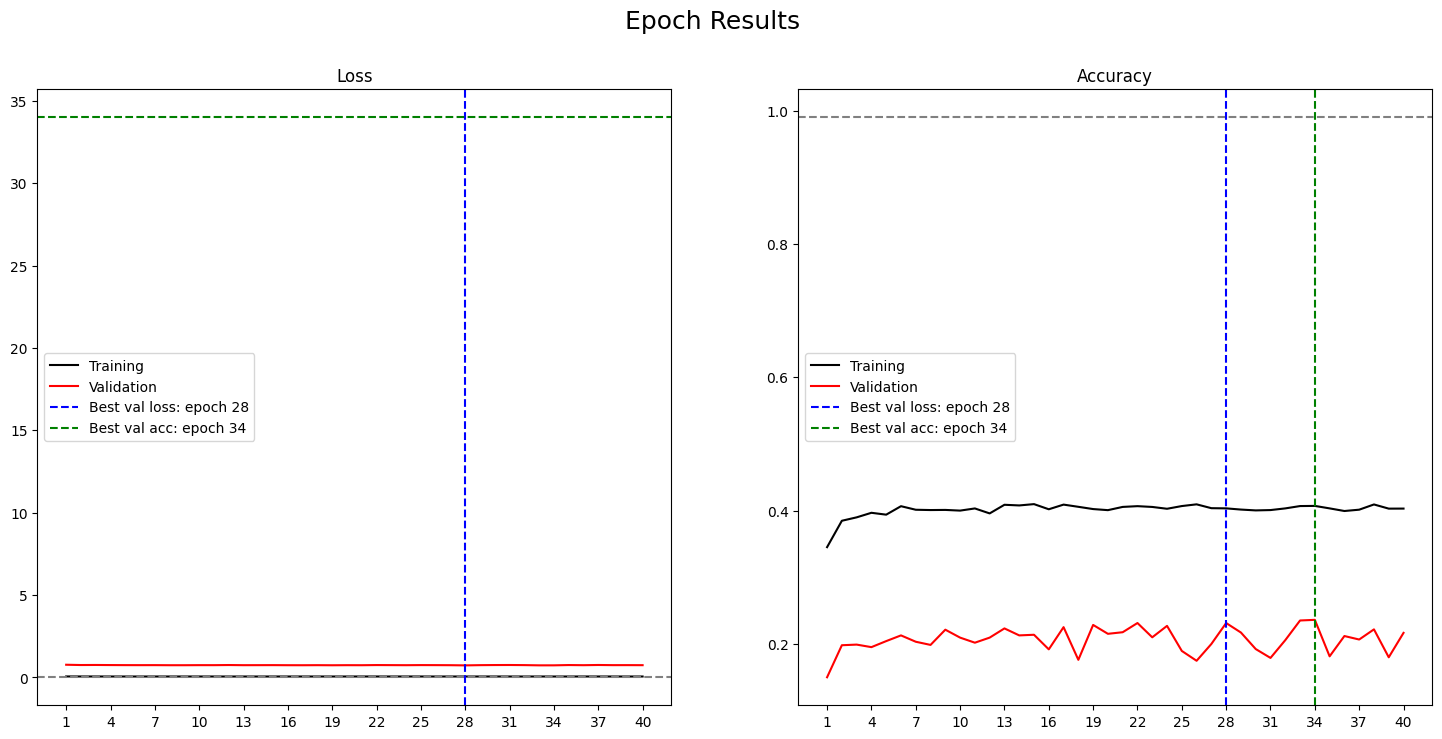

In [46]:
fig = plt.figure(figsize=(18, 8))
fig.suptitle("Epoch Results", fontsize = 18)

epochs_range = np.arange(1, CFG.N_EPOCHS + 1, 1)

# purely for visual ease, but not required cuz still understendable
if CFG.N_EPOCHS <= 20:
  x_ticks = np.arange(1, CFG.N_EPOCHS + 1, 1)
else:
  x_ticks = np.arange(1, CFG.N_EPOCHS + 1, int(CFG.N_EPOCHS/20) + 1)

# ================================ #

# Loss plot
ax1 = plt.subplot(1,2,1)
ax1.plot(epochs_range, train_loss_history, label="Training", color="black")
ax1.plot(epochs_range, valid_loss_history, label="Validation", color="red")
plt.xticks(x_ticks)

# draw horizontal line for best epoch loss
plt.axhline(0, linestyle="dashed", color="grey")
plt.axvline(best_epoch_loss, linestyle = "dashed", color="blue",
            label="Best val loss: epoch " + str(best_epoch_loss))

# draw vertical line for best epoch accuracy
plt.axhline(best_epoch_acc, linestyle = "dashed", color = "green",
            label = "Best val acc: epoch " + str(best_epoch_acc))
plt.title("Loss")
ax1.legend()

# ================================ #

# Accuracy Plot
ax2 = plt.subplot(1,2,2)
ax2.plot(epochs_range, train_acc_history, label="Training", color="black")
ax2.plot(epochs_range, valid_acc_history, label="Validation", color="red")
plt.xticks(x_ticks)

# draw horizontal line for best epoch accuracy
plt.axhline(0.99, linestyle="dashed", color="grey")
plt.axvline(best_epoch_loss, linestyle="dashed", color="blue",
            label="Best val loss: epoch " + str(best_epoch_loss))
plt.axvline(best_epoch_acc, linestyle="dashed", color="green",
            label="Best val acc: epoch " + str(best_epoch_acc))
plt.title("Accuracy")
ax2.legend()
plt.show()

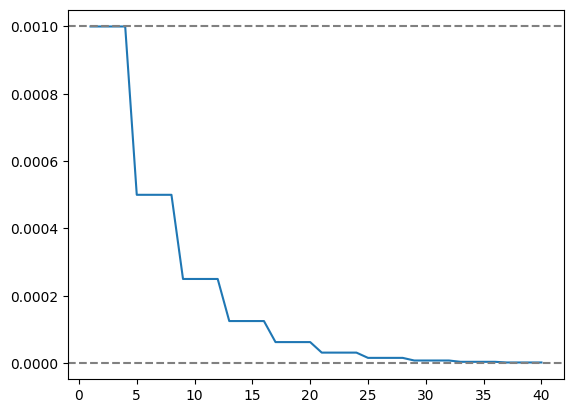

In [72]:
plt.plot(epochs_range, LR_history)
plt.axhline(0, linestyle="dashed", color="grey")
plt.axhline(CFG.LEARNING_RATE, linestyle="dashed", color="grey")

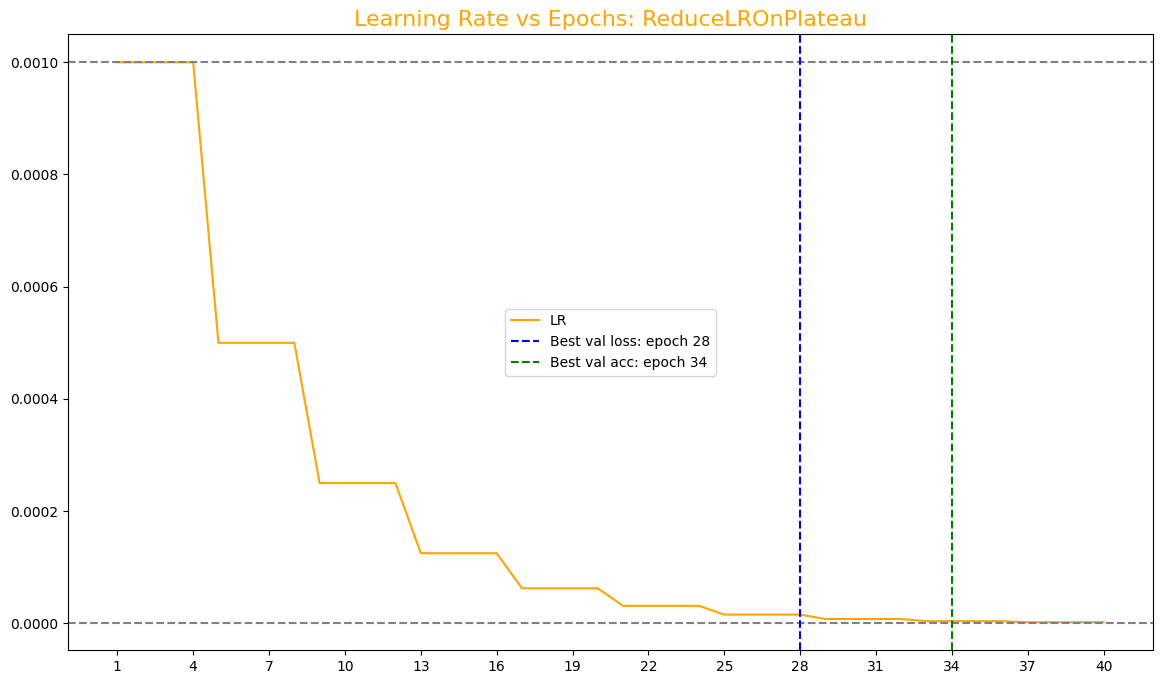

In [48]:
fig = plt.figure(figsize=(14, 8))

epochs_range = np.arange(1, CFG.N_EPOCHS + 1, 1)

if CFG.N_EPOCHS <= 20:
  x_ticks = np.arange(1, CFG.N_EPOCHS + 1, 1)
else:
  x_ticks = np.arange(1, CFG.N_EPOCHS + 1, int(CFG.N_EPOCHS/20) + 1)


# LR plot with scheduler
plt.plot(epochs_range, LR_history, label="LR", color="orange")
plt.xticks(x_ticks)

# draw horizontal line
plt.axhline(CFG.LEARNING_RATE, linestyle="dashed", color="grey")
plt.axhline(0, linestyle="dashed", color="grey")

# draw vertical lines
plt.axvline(best_epoch_loss, linestyle="dashed", color="blue",
            label="Best val loss: epoch " + str(best_epoch_loss))
plt.axvline(best_epoch_acc, linestyle="dashed", color="green",
            label="Best val acc: epoch " + str(best_epoch_acc))
plt.title(f"Learning Rate vs Epochs: {CFG.scheduler}", fontsize=16, color="orange")
plt.legend()
plt.show()

### Inference

In [62]:
import time

def softmax(x):
  return np.exp(x) / np.sum(np.exp(x), axis=1)[:, None]

def inference(test_loader, model):
  model.eval()

  predictions = []

  size = len(test_loader.dataset)
  num_batches = len(test_loader)

  model = DigitModel().to(device)

  if CFG.save_best_loss:
    model.load_state_dict(torch.load(OUTPUT_PATH + f"DigitModel_ep{best_epoch_loss}.pth"))
  else:
    model.load_state_dict(torch.load(OUTPUT_PATH + f"DigitModel_ep{best_epoch_acc}.pth"))

  with torch.inference_mode():
    for batch, X in enumerate(test_loader):
      start = time.time()

      current = batch * len(X)

      X = X.to(device)

      pred = model(X)

      # softmax/argmax along CLASS DIMENSIONS
      y_pred = torch.softmax(pred, dim=1)
      y_pred = torch.argmax(y_pred, dim=1)

      predictions.append(y_pred.cpu())

      end = time.time()
      time_delta = np.round(end - start, 5)

  test_predictions = np.concatenate(predictions, axis = 0)

  return test_predictions


In [63]:
inference_dataset = DigitInferenceDataset(test, augmentations=None)

inference_dataloader = DataLoader(
    inference_dataset,
    batch_size = CFG.BATCH_SIZE,
    shuffle = False
)

In [64]:
%%time

predictions = inference(inference_dataloader, model)

predictions

CPU times: user 5.83 s, sys: 34 ms, total: 5.87 s
Wall time: 6.58 s


array([8, 3, 9, ..., 3, 4, 2])

## Submission

In [65]:
submission = pd.read_csv(INPUT_PATH + "sample_submission.csv")
submission["Label"] = predictions

submission.to_csv(OUTPUT_PATH + "submission.csv", index = False)
submission.head()

,ImageId,Label
0,1,8
1,2,3
2,3,9
3,4,8
4,5,3


### Check predictions

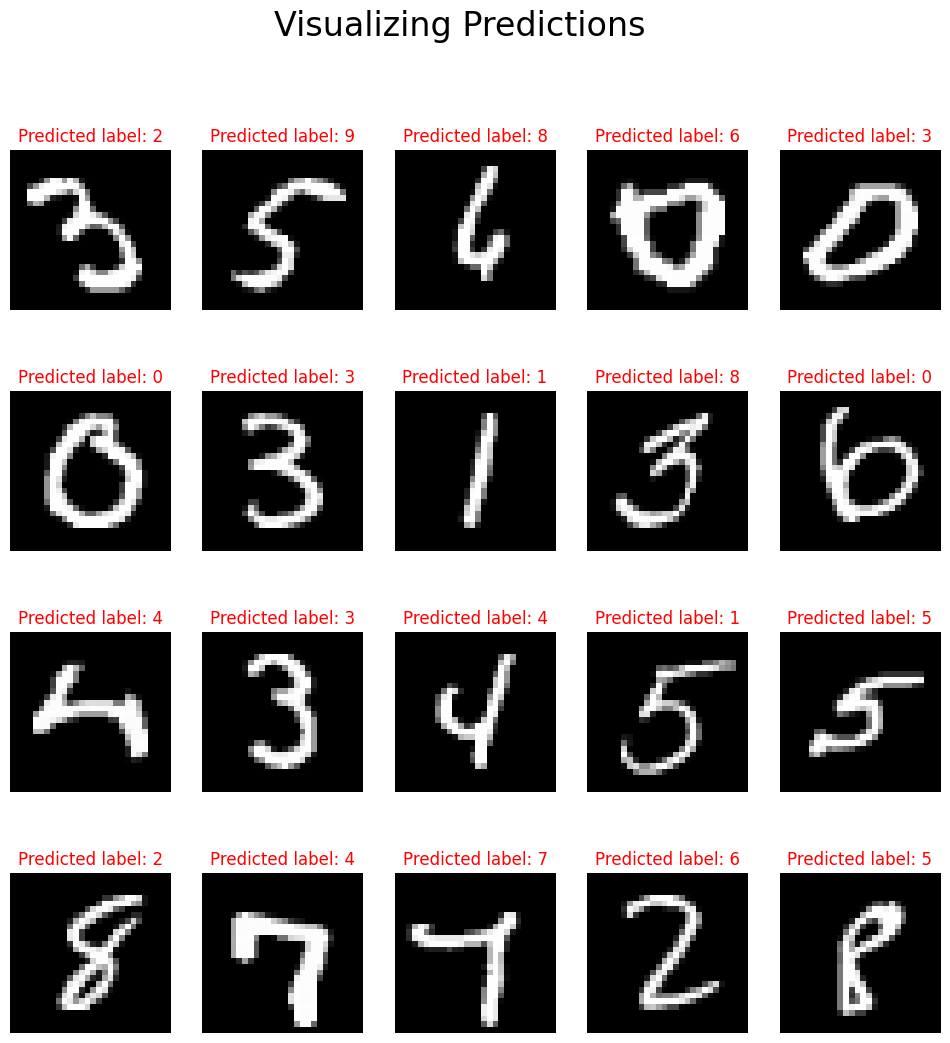

In [68]:
fig = plt.figure(figsize=(12,12))
fig.suptitle("Visualizing Predictions", fontsize=24)

begin = 130
end = begin + 20

for i in range(begin, end):
  img = np.array(test.iloc[i, :]).reshape(1, 1, 28, 28)
  plt.subplot(4, 5, i + 1 - begin)
  label = str(submission.loc[i, "Label"])
  plt.title("Predicted label: " + label, color="red")
  plt.imshow(np.squeeze(img), cmap="gray")
  plt.axis("off")

plt.show()